# Proyek Analisis Data: [E-commerce-public-dataset]
- **Nama:** [Muhammad Adil Imamul Haq Mubarak]
- **Email:** []
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

1. Bagaimana pengaruh musim (*season*) dan kondisi cuaca (*weathersit*) terhadap jumlah sewa sepeda harian?
2. Bagaimana tren penyewaan sepeda dalam setahun, dan apakah ada perbedaan pola antara hari kerja (*workingday*) dan hari libur (*holiday*)?
3. Pada jam berapa penyewaan sepeda mencapai puncaknya dalam sehari?

## Import Semua Packages/Library yang Digunakan

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [47]:
# Load dataset
day_df = pd.read_csv("data\\day.csv")
hour_df = pd.read_csv("data\\hour.csv")

# Menampilkan 5 baris pertama dari day_df
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Insight:

* **Struktur Data:** Dataset `day_df` berisi catatan harian penyewaan sepeda yang dimulai dari tanggal 1 Januari 2011. Data ini mencakup informasi waktu, kondisi cuaca, dan jumlah pengguna.
* **Normalisasi Fitur:** Variabel numerik seperti `temp`, `atemp`, `hum`, dan `windspeed` terlihat sudah melalui proses **normalisasi** (berada dalam rentang nilai 0 hingga 1). Hal ini sangat baik untuk pemodelan machine learning nantinya.
* **Komposisi Pengguna:** Kolom `cnt` merupakan variabel target yang merupakan hasil penjumlahan dari pengguna `casual` dan `registered`. 
    * *Contoh baris pertama:* $331 \text{ (casual)} + 654 \text{ (registered)} = 985 \text{ (total)}$.
* **Dominasi Pengguna:** Pada sampel 5 data pertama (awal Januari 2011), jumlah pengguna **Registered** jauh lebih tinggi dibandingkan pengguna **Casual**, yang mengindikasikan bahwa pada periode tersebut sepeda lebih banyak digunakan oleh pelanggan tetap atau komuter.
* **Kategorisasi Variabel:** Kolom seperti `season`, `yr`, `mnth`, dan `weathersit` sudah dalam bentuk angka (encoded), sehingga memudahkan analisis korelasi tanpa perlu transformasi string manual yang rumit.

### Assessing Data

In [56]:
datasets = {"Day Data": day_df, "Hour Data": hour_df}

for name, df in datasets.items():
    print(f"========== {name} ==========")
    print("1. INFO TIPE DATA:")
    df.info()
    
    print("\n2. JUMLAH MISSING VALUE:")
    print(df.isna().sum())
    
    print(f"\n3. JUMLAH DUPLIKASI: {df.duplicated().sum()}")
    print("-" * 40, "\n")

========== Day Data ==========
1. INFO TIPE DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   instant          731 non-null    int64         
 1   dteday           731 non-null    datetime64[ns]
 2   season           731 non-null    object        
 3   yr               731 non-null    object        
 4   mnth             731 non-null    object        
 5   holiday          731 non-null    int64         
 6   weekday          731 non-null    int64         
 7   workingday       731 non-null    object        
 8   weathersit       731 non-null    object        
 9   temp             731 non-null    float64       
 10  atemp            731 non-null    float64       
 11  hum              731 non-null    float64       
 12  windspeed        731 non-null    float64       
 13  casual           731 non-null    int64       

### Insight Analisis Dataset

#### 1. Kualitas Data (Cleanliness)
Berdasarkan pengecekan menggunakan `isna().sum()` dan `duplicated().sum()`, dataset tidak memiliki missing values (nilai kosong) maupun data duplikat. Hal ini menunjukkan bahwa data cukup bersih secara struktural dan siap untuk tahap analisis lebih lanjut tanpa preprocessing tambahan.

#### 2. Jumlah Observasi
Terdapat **731 baris data** pada `day_df`, yang mencerminkan data harian selama kurang lebih **2 tahun (2011–2012)**. Jumlah ini cukup representatif untuk melakukan analisis tren jangka menengah.

#### 3. Tipe Data (Data Types)
- Kolom `dteday` sudah bertipe **datetime64**, sehingga siap digunakan untuk analisis berbasis waktu (*time-series*) tanpa perlu konversi ulang.
- Beberapa fitur kategorikal seperti `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, dan `weathersit` terbaca sebagai **object** atau **int64**, yang masih bisa dioptimalkan dengan konversi ke tipe `category` jika diperlukan.
- Kolom `demand_category` sudah bertipe **category**, yang membantu menghemat memori dan meningkatkan efisiensi komputasi.

#### 4. Skala Numerik
Fitur cuaca seperti `temp`, `atemp`, `hum`, dan `windspeed` menggunakan tipe data **float64**, yang menunjukkan bahwa data kemungkinan sudah melalui proses normalisasi. Hal ini baik untuk menjaga presisi dalam analisis maupun pemodelan machine learning.

### Cleaning Data

In [50]:
# Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping kolom kategori pada day_df
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'})
day_df['yr'] = day_df['yr'].map({0: '2011', 1: '2012'})
day_df['mnth'] = day_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
day_df['workingday'] = day_df['workingday'].map({0: 'Holiday/Weekend', 1: 'Working Day'})

print("Data setelah proses cleaning dan mapping:")
print(day_df[['dteday', 'season', 'yr', 'mnth', 'weathersit', 'workingday']].head())

Data setelah proses cleaning dan mapping:
      dteday  season    yr mnth           weathersit       workingday
0 2011-01-01  Spring  2011  Jan         Misty/Cloudy  Holiday/Weekend
1 2011-01-02  Spring  2011  Jan         Misty/Cloudy  Holiday/Weekend
2 2011-01-03  Spring  2011  Jan  Clear/Partly Cloudy      Working Day
3 2011-01-04  Spring  2011  Jan  Clear/Partly Cloudy      Working Day
4 2011-01-05  Spring  2011  Jan  Clear/Partly Cloudy      Working Day


### Insight Transformasi Data

#### 1. Konversi Tipe Data
Kolom `dteday` telah berhasil diubah menjadi tipe data **datetime**. Hal ini memungkinkan kita untuk melakukan ekstraksi komponen waktu lebih lanjut (seperti jam, hari, bulan, atau kuartal) menggunakan atribut `.dt`, yang sangat berguna dalam analisis berbasis waktu (*time-series*).

#### 2. Transformasi Kategorikal (Mapping)
- Variabel numerik yang bersifat kategorikal seperti `season`, `weathersit`, `yr`, `mnth`, dan `workingday` telah diubah menjadi label deskriptif (contoh: `1 → Spring`, `0 → 2011`).
- Transformasi ini mempermudah interpretasi, terutama saat visualisasi data, karena grafik akan menampilkan label yang lebih informatif dibandingkan kode angka.

#### 3. Standarisasi Informasi
- Pengelompokan `workingday` menjadi **Working Day** dan **Holiday/Weekend** membantu membedakan pola perilaku pengguna antara hari kerja dan hari libur.
- Pemetaan `weathersit` memberikan gambaran kualitatif kondisi cuaca (misalnya: *Clear/Partly Cloudy* atau *Misty/Cloudy*), yang secara logis dapat memengaruhi keputusan pengguna untuk bersepeda.

#### 4. Kesiapan Data
Dataset kini berada dalam kondisi yang lebih **intuitif, terstruktur, dan mudah dipahami**. Dengan kondisi ini, data siap untuk tahap selanjutnya yaitu **Exploratory Data Analysis (EDA)** guna menemukan pola-pola tersembunyi, seperti musim dengan tingkat penyewaan tertinggi atau pengaruh cuaca terhadap jumlah pengguna.

## Exploratory Data Analysis (EDA)

### Explore ...

In [51]:
# Membuat kriteria Binning
bins = [0, 2500, 5500, float('inf')]
labels = ['Low Demand', 'Medium Demand', 'High Demand']

# Menerapkan cut untuk mengkategorikan data
day_df['demand_category'] = pd.cut(day_df['cnt'], bins=bins, labels=labels)

print("Distribusi Kategori Permintaan Sepeda Harian:")
print(day_df['demand_category'].value_counts())

Distribusi Kategori Permintaan Sepeda Harian:
demand_category
Medium Demand    364
High Demand      223
Low Demand       144
Name: count, dtype: int64


### Insight Exploratory Data Analysis (EDA)

#### 1. Distribusi Permintaan
Mayoritas hari dalam dataset termasuk ke dalam kategori:
- **Medium Demand**: 364 hari  
- **High Demand**: 223 hari  
- **Low Demand**: 144 hari  

Hal ini menunjukkan bahwa sistem penyewaan sepeda memiliki tingkat penggunaan yang **cukup stabil dan cenderung tinggi** pada sebagian besar waktu.

#### 2. Segmentasi Bisnis
- **Medium Demand**  
  Merupakan kategori yang paling dominan (sekitar **50% dari total data**), mencerminkan performa bisnis harian yang **konsisten**.

- **High Demand**  
  Terdapat **223 hari** dengan permintaan tinggi (lebih dari 5500 penyewaan). Ini adalah periode krusial yang membutuhkan:
  - Ketersediaan armada maksimal  
  - Manajemen operasional yang optimal  

- **Low Demand**  
  Hanya terjadi pada **144 hari**, menjadikannya kategori paling jarang. Kondisi ini membuka peluang analisis lebih lanjut, seperti:
  - Pengaruh cuaca ekstrem  
  - Dampak hari libur atau kondisi tertentu terhadap penurunan permintaan  

#### 3. Potensi Analisis Lanjutan
Dengan adanya kolom `demand_category`, analisis dapat dikembangkan lebih lanjut menggunakan:
- **Cross-tabulation (tabulasi silang)** untuk melihat hubungan antar variabel  
- Analisis pengaruh faktor eksternal seperti:
  - `season` terhadap **High Demand**
  - `weathersit` terhadap **Low Demand**

Pendekatan ini akan membantu mengidentifikasi pola tersembunyi dan menghasilkan insight yang lebih strategis untuk pengambilan keputusan bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_18364\2272159375.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=day_df, ax=ax[0], palette='viridis', errorbar=None)
C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_18364\2272159375.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weathersit', y='cnt', data=day_df, ax=ax[1], palette='coolwarm', errorbar=None)


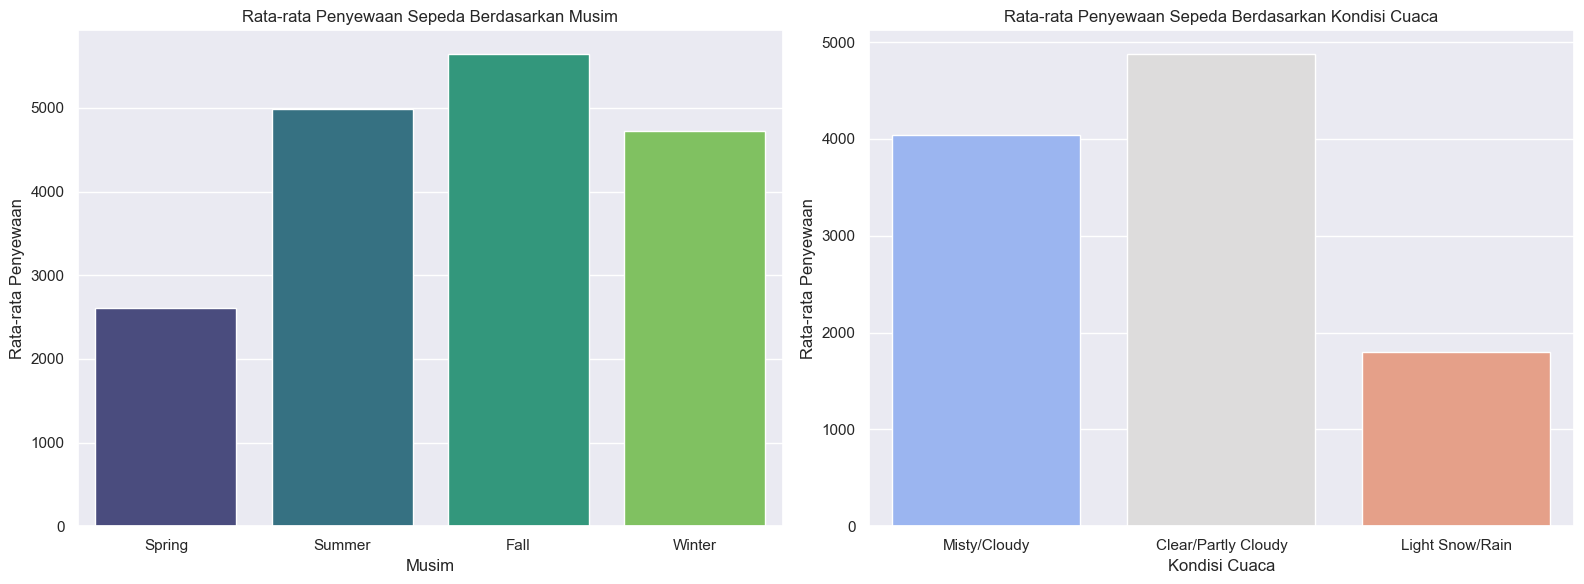

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi Musim
sns.barplot(x='season', y='cnt', data=day_df, ax=ax[0], palette='viridis', errorbar=None)
ax[0].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Musim')
ax[0].set_xlabel('Musim')
ax[0].set_ylabel('Rata-rata Penyewaan')

# Visualisasi Cuaca
sns.barplot(x='weathersit', y='cnt', data=day_df, ax=ax[1], palette='coolwarm', errorbar=None)
ax[1].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
ax[1].set_xlabel('Kondisi Cuaca')
ax[1].set_ylabel('Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

## Insight Visualisasi & Explanatory Analysis

### 1. Pengaruh Musim terhadap Penyewaan
- **Musim Fall (Gugur)** menjadi periode dengan rata-rata penyewaan tertinggi, diikuti oleh **Musim Summer (Panas)**. Hal ini menunjukkan bahwa pengguna cenderung lebih aktif bersepeda saat cuaca hangat dan nyaman.
- **Musim Spring (Semi)** memiliki tingkat penyewaan terendah. Kemungkinan disebabkan oleh kondisi cuaca transisi yang kurang stabil sehingga memengaruhi kenyamanan pengguna.

### 2. Pengaruh Kondisi Cuaca
- Terdapat hubungan yang sangat kuat antara kondisi cuaca dan jumlah penyewaan.
- Kondisi **Clear/Partly Cloudy** menghasilkan rata-rata penyewaan tertinggi (mendekati 5000 unit), menandakan cuaca cerah sangat mendukung aktivitas bersepeda.
- Sebaliknya, kondisi **Light Snow/Rain** menyebabkan penurunan signifikan pada jumlah penyewaan, yang dapat dikaitkan dengan faktor keamanan dan kenyamanan pengguna.

### 3. Kesimpulan Strategis
- **Optimalisasi Operasional**  
  Fokuskan kesiapan armada pada:
  - Musim **Fall** dan **Summer**
  - Hari dengan prakiraan cuaca **cerah**

- **Strategi Peningkatan Permintaan**  
  Terapkan strategi seperti:
  - Promo atau diskon pada **Musim Spring**
  - Penawaran khusus saat cuaca **Misty/Cloudy**

Pendekatan ini dapat membantu menjaga stabilitas penggunaan sepeda serta mengoptimalkan performa bisnis secara keseluruhan.

### Pertanyaan 2:

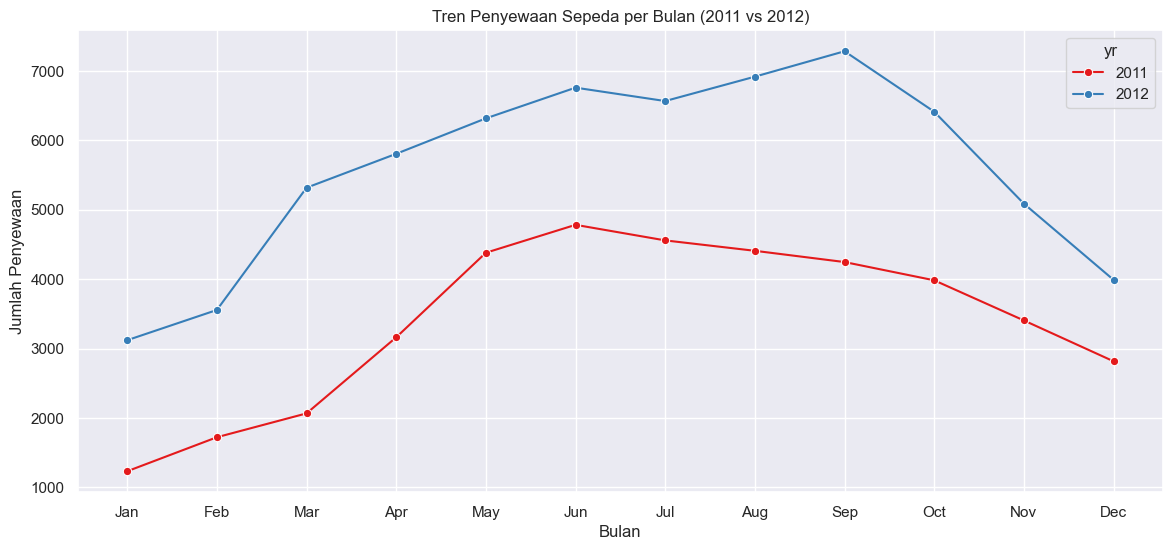

C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_18364\3988265687.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='workingday', y='cnt', data=day_df, palette='pastel')


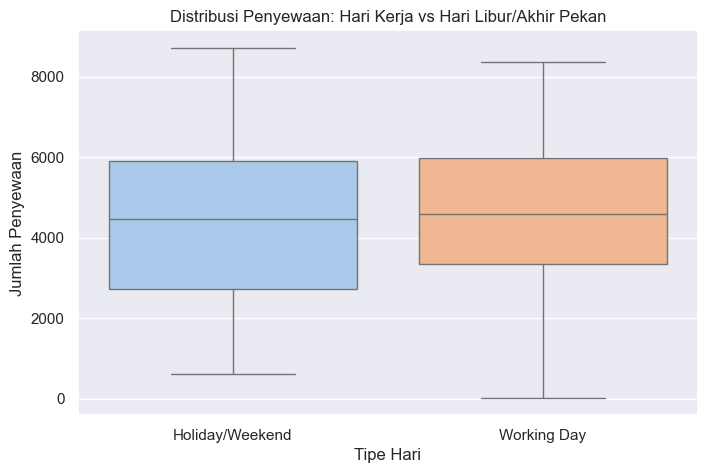

In [53]:
plt.figure(figsize=(14, 6))

# Visualisasi Tren Bulanan dibedakan berdasarkan tahun
sns.lineplot(x='mnth', y='cnt', hue='yr', data=day_df, marker='o', palette='Set1', errorbar=None)
plt.title('Tren Penyewaan Sepeda per Bulan (2011 vs 2012)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')
plt.show()

# Visualisasi Hari Kerja vs Libur
plt.figure(figsize=(8, 5))
sns.boxplot(x='workingday', y='cnt', data=day_df, palette='pastel')
plt.title('Distribusi Penyewaan: Hari Kerja vs Hari Libur/Akhir Pekan')
plt.xlabel('Tipe Hari')
plt.ylabel('Jumlah Penyewaan')
plt.show()

### Insight Visualisasi & Explanatory Analysis (Pertanyaan 2)

#### 1. Pertumbuhan Tahunan (Year-over-Year Growth)
- Terjadi peningkatan jumlah penyewaan yang **sangat signifikan** dari tahun **2011 ke 2012**.
- Garis tren tahun 2012 secara konsisten berada di atas tahun 2011 pada setiap bulan.
- Hal ini menunjukkan bahwa layanan bike-sharing mengalami:
  - Pertumbuhan popularitas  
  - Peningkatan jumlah pengguna secara pesat  

#### 2. Pola Musiman Bulanan
- Kedua tahun menunjukkan pola musiman yang serupa:
  - Mulai meningkat pada **bulan Maret**
  - Mencapai puncak pada **Juni hingga September**
  - Menurun drastis pada **November – Desember**
- Puncak tertinggi terjadi pada **September 2012**, yang menjadi periode dengan permintaan maksimal.

#### 3. Analisis Hari Kerja vs Hari Libur (Boxplot)
- **Working Day** memiliki nilai median penyewaan yang sedikit lebih tinggi dibandingkan **Holiday/Weekend**.
- Hal ini mengindikasikan bahwa penggunaan sepeda lebih banyak didorong oleh:
  - Aktivitas rutin (kerja/sekolah)
  - Kebutuhan transportasi harian  

- Rentang interkuartil (box) pada hari kerja lebih rapat, yang berarti:
  - Pola penggunaan lebih **stabil**
  - Lebih **mudah diprediksi** dibandingkan hari libur  

#### 4. Kesimpulan Operasional
- **Antisipasi Lonjakan Permintaan**
  - Lakukan perawatan dan persiapan armada sebelum periode puncak (**sebelum Juni**)

- **Fokus Distribusi Armada**
  - Prioritaskan ketersediaan sepeda pada:
    - Area perkantoran  
    - Titik transportasi publik  

- **Optimasi Berbasis Pola Penggunaan**
  - Karena hari kerja mendominasi, strategi operasional sebaiknya berfokus pada kebutuhan mobilitas harian pengguna

### Pertanyaan 3

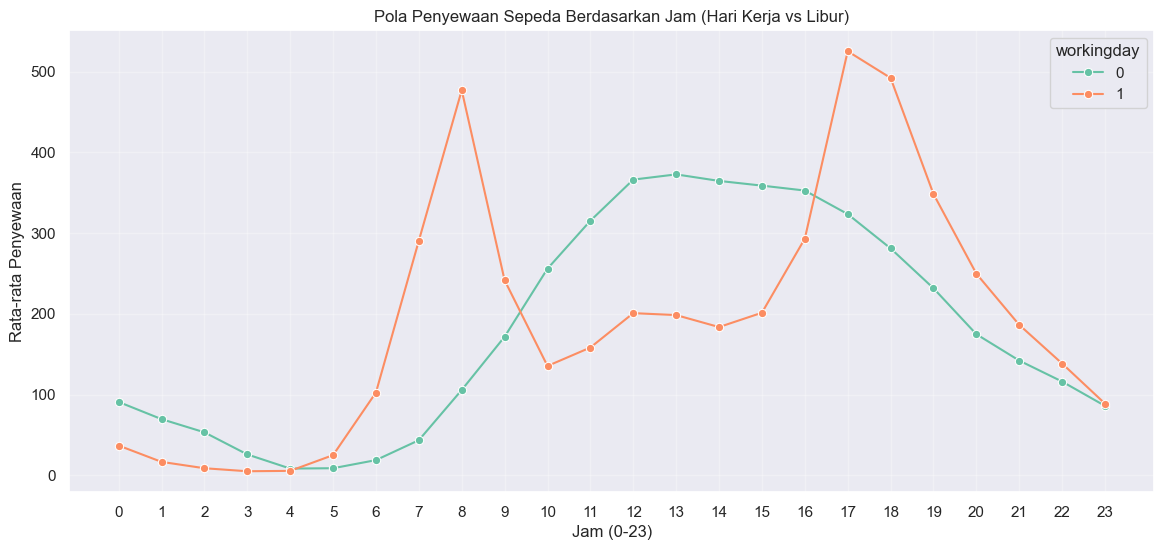

In [54]:
plt.figure(figsize=(14, 6))

# Rata-rata penyewaan berdasarkan jam kerja vs jam libur
sns.lineplot(x='hr', y='cnt', hue='workingday', data=hour_df, marker='o', palette='Set2', errorbar=None)
plt.title('Pola Penyewaan Sepeda Berdasarkan Jam (Hari Kerja vs Libur)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

### Insight Visualisasi & Explanatory Analysis (Pertanyaan 3)

#### 1. Pola Hari Kerja (Working Day)
- Terlihat pola **bimodal (dua puncak)** yang sangat jelas:
  - Puncak pertama: sekitar **08:00 pagi**
  - Puncak kedua: sekitar **17:00 – 18:00 sore**
- Pola ini mengindikasikan bahwa penggunaan sepeda didominasi oleh **aktivitas komuter**, seperti berangkat dan pulang kerja/sekolah.

#### 2. Pola Hari Libur / Akhir Pekan (Holiday/Weekend)
- Menunjukkan pola **unimodal (satu puncak landai)**:
  - Permintaan mulai meningkat sejak **09:00 pagi**
  - Mencapai puncak pada **12:00 – 15:00 siang**
- Pola ini mencerminkan penggunaan untuk **aktivitas rekreasi**, dengan waktu mulai yang lebih santai dibanding hari kerja.

#### 3. Titik Pertemuan (Cross-over)
- Pada rentang waktu **12:00 – 14:00**, jumlah penyewaan di hari libur **lebih tinggi** dibanding hari kerja.
- Hal ini menunjukkan adanya **potensi pasar rekreasi yang besar** pada siang hari di akhir pekan.

#### 4. Kesimpulan Operasional
- **Manajemen Logistik Armada**
  - Pastikan ketersediaan sepeda maksimal:
    - Di area pemukiman sekitar **07:00 pagi**
    - Di area perkantoran sekitar **16:00 sore**

- **Strategi Pemeliharaan**
  - Waktu optimal untuk maintenance:
    - Jam rendah aktivitas (**10:00 – 15:00**)
    - Atau setelah **22:00 malam**

Pendekatan ini membantu meningkatkan efisiensi operasional sekaligus menjaga ketersediaan layanan sesuai pola kebutuhan pengguna.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1
- Conclution pertanyaan 2

In [55]:
# Simpan data utama ke dalam file CSV baru
day_df.to_csv("main_data.csv", index=False)
print("Data berhasil disimpan ke main_data.csv")

Data berhasil disimpan ke main_data.csv
